<a href="https://colab.research.google.com/github/habibiputrar/Habibi-Putra-Rizqullah_2411531001_ML2526/blob/main/Praktikum5/TugasCrossValidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport.")

Library berhasil diimport.


Proses import library merupakan tahap inisialisasi yang wajib dilakukan. Penggunaan warnings.filterwarnings('ignore') bertujuan untuk menyembunyikan pesan peringatan yang tidak relevan sehingga output menjadi lebih bersih.

## 2. Load & Gabungkan 3 Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/ML/Dataset/"

df_train      = pd.read_csv(BASE_PATH + "train.csv")
df_test       = pd.read_csv(BASE_PATH + "test.csv")
df_submission = pd.read_csv(BASE_PATH + "gender_submission.csv")

print("Shape train.csv            :", df_train.shape)
print("Shape test.csv             :", df_test.shape)
print("Shape gender_submission.csv:", df_submission.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape train.csv            : (891, 12)
Shape test.csv             : (418, 11)
Shape gender_submission.csv: (418, 2)


In [ ]:
# Gabungkan test.csv dengan gender_submission.csv untuk mendapatkan kolom Survived
df_test_labeled = pd.merge(df_test, df_submission, on='PassengerId')

print("Shape test setelah digabung dengan label:", df_test_labeled.shape)
df_test_labeled.head()

Shape test setelah digabung dengan label: (418, 12)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,1


In [ ]:
# Gabungkan train + test_labeled menjadi satu dataset lengkap
df = pd.concat([df_train, df_test_labeled], ignore_index=True)

print("Shape dataset gabungan:", df.shape)
print("\nDistribusi kelas Survived:")
print(df['Survived'].value_counts())
df.head()

Shape dataset gabungan: (1309, 12)

Distribusi kelas Survived:
Survived
0    815
1    494
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Penggabungan ketiga file menghasilkan dataset dengan 1.309 baris dan 12 kolom. Distribusi kelas yang diperoleh yaitu 815 penumpang tidak selamat (62.3%) dan 494 penumpang selamat (37.7%) menunjukkan ketidakseimbangan kelas yang moderat. Hal ini menjadi alasan utama penggunaan Stratified K-Fold agar proporsi kelas tetap terjaga pada setiap fold.

In [ ]:
# Cek missing values
print("Missing Values per Kolom:")
print(df.isnull().sum())

Missing Values per Kolom:
PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64


## 3. Praproses Data (Preprocessing)

In [ ]:
df_clean = df.copy()

# (1) Hapus kolom tidak relevan
df_clean.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

# (2) Imputasi missing values
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
df_clean['Fare'].fillna(df_clean['Fare'].median(), inplace=True)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# (3) Encoding fitur kategorikal
le = LabelEncoder()
df_clean['Sex']      = le.fit_transform(df_clean['Sex'])       # female=0, male=1
df_clean['Embarked'] = le.fit_transform(df_clean['Embarked'])  # C=0, Q=1, S=2

print("Missing values setelah praproses:")
print(df_clean.isnull().sum())
print("\nShape akhir:", df_clean.shape)
df_clean.head()

Missing values setelah praproses:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Shape akhir: (1309, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


Kolom PassengerId, Name, Ticket, dan Cabin dihapus karena tidak memberikan informasi prediktif. Cabin dihapus karena 77% nilainya hilang sehingga imputasi tidak akan menghasilkan data yang representatif. Missing values pada Age (263) dan Fare (1) diisi dengan nilai median agar tidak sensitif terhadap outlier. Embarked (2 missing) diisi dengan modus. Encoding menghasilkan female=0/male=1 untuk Sex, dan C=0/Q=1/S=2 untuk Embarked.

In [ ]:
# Pisahkan fitur (X) dan target (y)
X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived'].astype(int)

print("Fitur (X):", X.columns.tolist())
print("Shape X  :", X.shape)
print("Shape y  :", y.shape)
print("\nDistribusi y:")
print(y.value_counts())

Fitur (X): ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Shape X  : (1309, 7)
Shape y  : (1309,)

Distribusi y:
Survived
0    815
1    494
Name: count, dtype: int64


Kolom Survived dipisahkan sebagai variabel target y, sementara tujuh kolom lainnya dijadikan variabel fitur X. Distribusi y mencerminkan ketidakseimbangan kelas yang sudah teridentifikasi sebelumnya.

In [ ]:
# Normalisasi fitur numerik
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Fitur setelah scaling (5 baris pertama):")
print(X_scaled[:5])

Fitur setelah scaling (5 baris pertama):
[[ 0.84191642  0.74349692 -0.58162831  0.48128777 -0.4449995  -0.50329106
   0.62227932]
 [-1.54609786 -1.34499549  0.65865194  0.48128777 -0.4449995   0.73474365
  -1.83492621]
 [ 0.84191642 -1.34499549 -0.27155825 -0.47908676 -0.4449995  -0.49024046
   0.62227932]
 [-1.54609786 -1.34499549  0.42609939  0.48128777 -0.4449995   0.3831835
   0.62227932]
 [ 0.84191642  0.74349692  0.42609939 -0.47908676 -0.4449995  -0.48782368
   0.62227932]]


StandardScaler mentransformasi setiap fitur sehingga memiliki rata-rata 0 dan standar deviasi 1. Normalisasi ini penting terutama untuk Logistic Regression yang sensitif terhadap perbedaan skala antar fitur. Fitur Age (0-80) dan Fare (0-512) yang memiliki skala jauh berbeda dari fitur lainnya akan mendapat manfaat terbesar dari proses ini.

## 4. K-Fold Cross Validation – Manual

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_lr = LogisticRegression(max_iter=1000)

acc_list, prec_list, rec_list, f1_list, auc_list = [], [], [], [], []

print("=== K-Fold Cross Validation Manual (5 Fold) – Logistic Regression ===")
print(f"{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<10} {'F1-Score':<12} {'ROC-AUC'}")
print("-" * 65)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), start=1):
    X_train_k, X_test_k = X_scaled[train_idx], X_scaled[test_idx]
    y_train_k, y_test_k = y.iloc[train_idx], y.iloc[test_idx]

    model_lr.fit(X_train_k, y_train_k)
    y_pred_k = model_lr.predict(X_test_k)
    y_prob_k = model_lr.predict_proba(X_test_k)[:, 1]

    acc  = accuracy_score(y_test_k, y_pred_k)
    prec = precision_score(y_test_k, y_pred_k)
    rec  = recall_score(y_test_k, y_pred_k)
    f1   = f1_score(y_test_k, y_pred_k)
    auc  = roc_auc_score(y_test_k, y_prob_k)

    acc_list.append(acc); prec_list.append(prec)
    rec_list.append(rec); f1_list.append(f1); auc_list.append(auc)

    print(f"{fold:<6} {acc:<12.4f} {prec:<12.4f} {rec:<10.4f} {f1:<12.4f} {auc:.4f}")

print("-" * 65)
print(f"{'Mean':<6} {np.mean(acc_list):<12.4f} {np.mean(prec_list):<12.4f} {np.mean(rec_list):<10.4f} {np.mean(f1_list):<12.4f} {np.mean(auc_list):.4f}")
print(f"{'Std':<6} {np.std(acc_list):<12.4f} {np.std(prec_list):<12.4f} {np.std(rec_list):<10.4f} {np.std(f1_list):<12.4f} {np.std(auc_list):.4f}")

=== K-Fold Cross Validation Manual (5 Fold) – Logistic Regression ===
Fold   Accuracy     Precision    Recall     F1-Score     ROC-AUC
-----------------------------------------------------------------
1      0.8435       0.7788       0.8182     0.7980       0.9104
2      0.8168       0.8000       0.6869     0.7391       0.8404
3      0.8855       0.8710       0.8182     0.8438       0.9125
4      0.8664       0.8556       0.7778     0.8148       0.9134
5      0.8391       0.8111       0.7449     0.7766       0.8976
-----------------------------------------------------------------
Mean   0.8503       0.8233       0.7692     0.7945       0.8949
Std    0.0236       0.0346       0.0495     0.0353       0.0278


Logistic Regression menghasilkan accuracy rata-rata 0.8503 dengan standar deviasi 0.0236 yang relatif kecil, menunjukkan model yang stabil antar fold. Fold 3 menghasilkan performa terbaik (accuracy 0.8855, ROC-AUC 0.9125) sementara Fold 2 menghasilkan performa terendah (accuracy 0.8168). Nilai ROC-AUC rata-rata 0.8949 mengindikasikan kemampuan diskriminasi yang sangat baik.

## 5. K-Fold Cross Validation – Menggunakan cross_val_score

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(LogisticRegression(max_iter=1000), X_scaled, y, cv=skf, scoring='accuracy')
cv_f1       = cross_val_score(LogisticRegression(max_iter=1000), X_scaled, y, cv=skf, scoring='f1')
cv_roc_auc  = cross_val_score(LogisticRegression(max_iter=1000), X_scaled, y, cv=skf, scoring='roc_auc')

print("=== K-Fold dengan cross_val_score ===")
print(f"\nAccuracy  per fold : {np.round(cv_accuracy, 4)}")
print(f"Accuracy rata-rata : {cv_accuracy.mean():.4f} +/- {cv_accuracy.std():.4f}")
print(f"\nF1-Score  per fold : {np.round(cv_f1, 4)}")
print(f"F1 rata-rata       : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}")
print(f"\nROC-AUC   per fold : {np.round(cv_roc_auc, 4)}")
print(f"ROC-AUC rata-rata  : {cv_roc_auc.mean():.4f} +/- {cv_roc_auc.std():.4f}")

=== K-Fold dengan cross_val_score ===

Accuracy  per fold : [0.8435 0.8168 0.8855 0.8664 0.8391]
Accuracy rata-rata : 0.8503 +/- 0.0236

F1-Score  per fold : [0.798  0.7391 0.8438 0.8148 0.7766]
F1 rata-rata       : 0.7945 +/- 0.0353

ROC-AUC   per fold : [0.9104 0.8404 0.9125 0.9134 0.8976]
ROC-AUC rata-rata  : 0.8949 +/- 0.0278


Hasil cross_val_score konsisten dengan hasil K-Fold manual, membuktikan keduanya menggunakan mekanisme yang sama. Nilai rata-rata accuracy 0.8503 ± 0.0236, F1-Score 0.7945 ± 0.0353, dan ROC-AUC 0.8949 ± 0.0278 memberikan gambaran performa yang stabil dengan standar deviasi yang rendah.



## 6. Perbandingan Beberapa Model dengan K-Fold CV

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("=== Perbandingan Model dengan 5-Fold CV ===")
print(f"{'Model':<22} {'Accuracy':<22} {'F1-Score':<22} {'ROC-AUC'}")
print("-" * 80)

for name, model in models.items():
    acc = cross_val_score(model, X_scaled, y, cv=skf, scoring='accuracy')
    f1  = cross_val_score(model, X_scaled, y, cv=skf, scoring='f1')
    auc = cross_val_score(model, X_scaled, y, cv=skf, scoring='roc_auc')
    results[name] = {'Accuracy': acc, 'F1': f1, 'ROC-AUC': auc}
    print(f"{name:<22} {acc.mean():.4f} +/- {acc.std():.4f}    {f1.mean():.4f} +/- {f1.std():.4f}    {auc.mean():.4f} +/- {auc.std():.4f}")

=== Perbandingan Model dengan 5-Fold CV ===
Model                  Accuracy               F1-Score               ROC-AUC
--------------------------------------------------------------------------------
Logistic Regression    0.8503 +/- 0.0236    0.7945 +/- 0.0353    0.8949 +/- 0.0278
Decision Tree          0.8235 +/- 0.0286    0.7654 +/- 0.0358    0.8169 +/- 0.0301
Random Forest          0.8335 +/- 0.0284    0.7764 +/- 0.0393    0.8893 +/- 0.0315


Logistic Regression unggul dalam Accuracy (0.8503) dan F1-Score (0.7945), sementara Random Forest menghasilkan ROC-AUC tertinggi (0.8893). Decision Tree menghasilkan performa terendah di semua metrik, konsisten dengan karakternya yang cenderung overfit. Standar deviasi antar fold untuk semua model relatif kecil (< 0.04), mengindikasikan stabilitas model yang baik.

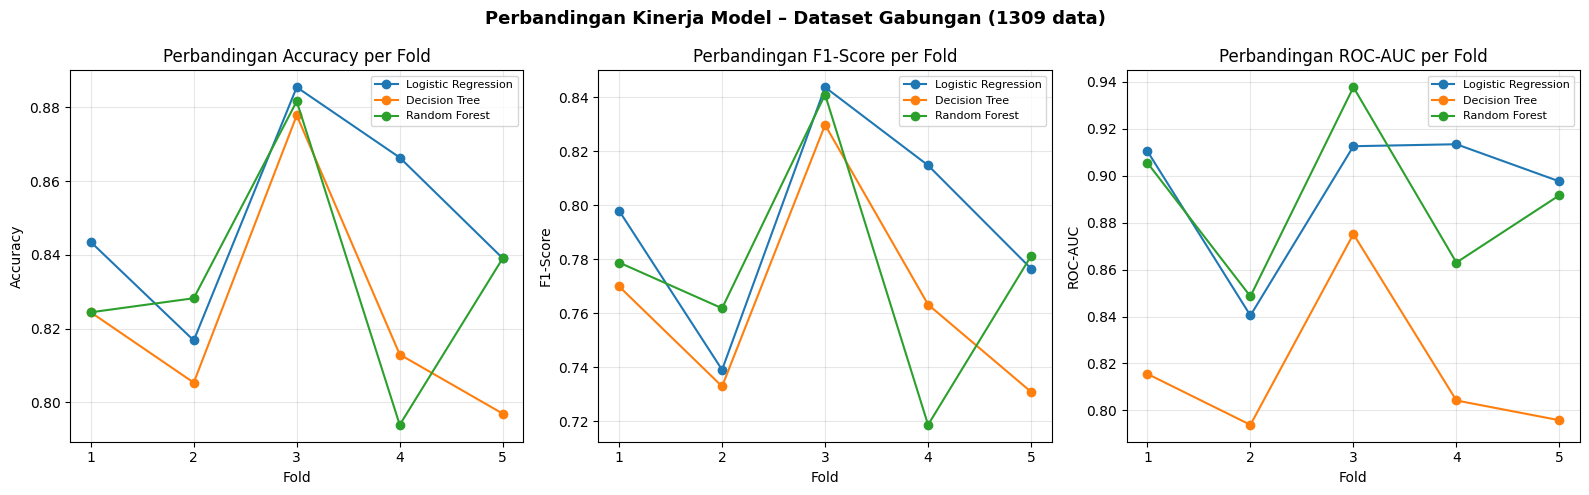

In [ ]:
# Visualisasi perbandingan metrik antar model per fold
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_keys = ['Accuracy', 'F1', 'ROC-AUC']
titles       = ['Accuracy', 'F1-Score', 'ROC-AUC']

for ax, key, title in zip(axes, metrics_keys, titles):
    for name in models:
        ax.plot(range(1, 6), results[name][key], marker='o', label=name)
    ax.set_title(f'Perbandingan {title} per Fold')
    ax.set_xlabel('Fold')
    ax.set_ylabel(title)
    ax.legend(fontsize=8)
    ax.set_xticks(range(1, 6))
    ax.grid(True, alpha=0.3)

plt.suptitle('Perbandingan Kinerja Model – Dataset Gabungan (1309 data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Dari ketiga grafik yang ditampilkan, Logistic Regression memiliki performa paling stabil di setiap fold untuk semua metrik. Decision Tree cenderung tidak konsisten dengan nilai yang naik turun cukup drastis antar fold. Random Forest berada di antara keduanya, cukup baik namun sesekali turun pada fold tertentu. Secara umum, Fold 3 menjadi titik tertinggi bagi hampir semua model di ketiga metrik.

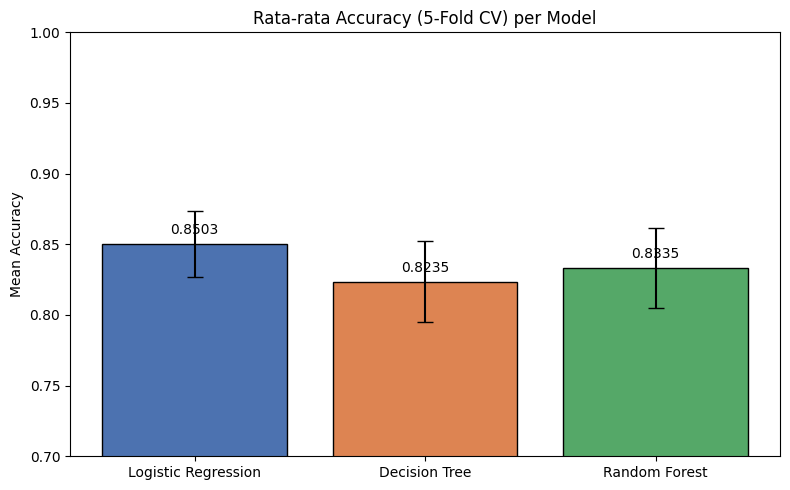

In [ ]:
# Bar chart rata-rata accuracy per model
model_names = list(results.keys())
mean_acc = [results[m]['Accuracy'].mean() for m in model_names]
std_acc  = [results[m]['Accuracy'].std()  for m in model_names]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, mean_acc, yerr=std_acc, capsize=6,
               color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
plt.ylim(0.7, 1.0)
plt.ylabel('Mean Accuracy')
plt.title('Rata-rata Accuracy (5-Fold CV) per Model')
for bar, val in zip(bars, mean_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

Bar chart menunjukkan rata-rata accuracy ketiga model selama 5 fold. Logistic Regression memperoleh nilai tertinggi sebesar 0.8503, diikuti Random Forest dengan 0.8335, dan Decision Tree dengan nilai terendah 0.8235. Error bar pada setiap batang menggambarkan standar deviasi antar fold  Decision Tree memiliki error bar paling panjang, menandakan hasil yang kurang konsisten dibanding dua model lainnya.

## 7. Confusion Matrix


=== Classification Report (Random Forest) ===
                   precision    recall  f1-score   support

Tidak Selamat (0)       0.84      0.88      0.86       163
      Selamat (1)       0.79      0.73      0.76        99

         accuracy                           0.82       262
        macro avg       0.82      0.81      0.81       262
     weighted avg       0.82      0.82      0.82       262



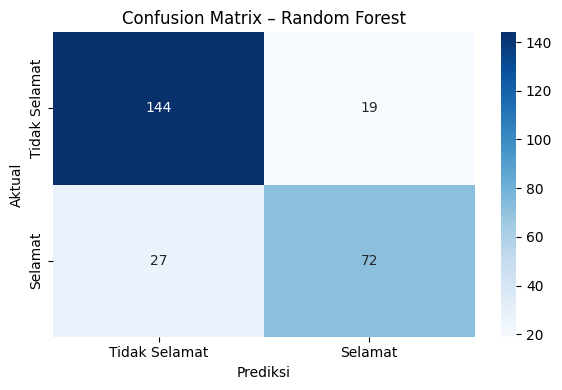

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("=== Classification Report (Random Forest) ===")
print(classification_report(y_test, y_pred, target_names=['Tidak Selamat (0)', 'Selamat (1)']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Selamat', 'Selamat'],
            yticklabels=['Tidak Selamat', 'Selamat'])
plt.title('Confusion Matrix – Random Forest')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.show()

Confusion matrix menunjukkan bahwa dari 163 penumpang yang tidak selamat, model berhasil mengklasifikasikan 144 dengan benar (TN) dan salah mengklasifikasikan 19 sebagai selamat (FP). Dari 99 penumpang yang selamat, model berhasil mengklasifikasikan 72 dengan benar (TP) dan salah mengklasifikasikan 27 sebagai tidak selamat (FN). Total accuracy pada test set adalah 82% ((144+72)/262).

## **Analisis Pengaruh Cross Validation terhadap Evaluasi Model**

Penggunaan Stratified K-Fold Cross Validation memberikan tiga keunggulan utama dalam evaluasi model klasifikasi Titanic ini. Pertama, dengan proporsi kelas yang terjaga di setiap fold (±62% tidak selamat, ±38% selamat), setiap iterasi pengujian menghasilkan kondisi yang representatif terhadap distribusi data keseluruhan. Hal ini tidak terjamin pada holdout biasa yang bergantung pada keacakan pembagian data.

Kedua, nilai standar deviasi yang rendah pada semua model (< 0.04 untuk semua metrik) membuktikan estimasi performa dari K-Fold sangat stabil. Seandainya menggunakan satu kali holdout, performa yang dilaporkan bisa kebetulan sangat baik atau buruk tergantung partisi yang terpilih. Ketiga, K-Fold memungkinkan seluruh 1.309 data digunakan sebagai data uji secara bergantian sehingga tidak ada data yang terbuang hanya untuk validasi — efisiensi ini sangat berharga untuk dataset berukuran terbatas.
